# Predicting Life Expectancy Using Socioeconomic and Health Indicators

## Problem Definition

### **Problem Statement**
Life expectancy is a key indicator of a nation's health and development. Understanding which socioeconomic and health factors have the strongest influence on life expectancy can help policymakers and organizations prioritize interventions to improve public health outcomes.

### **Research Question**
**Which socioeconomic and health indicators are most strongly associated with life expectancy across countries?**

### **Machine Learning Problem Type**
**Regression** — We are predicting a continuous numerical target variable (Life Expectancy in years) based on multiple predictor variables (socioeconomic and health indicators).

### **Dataset Overview**
- **Source**: World Health Organization (WHO) Life Expectancy Data
- **Time Period**: 2000-2015
- **Countries**: 193 countries (both developed and developing)
- **Target Variable**: Life Expectancy (years)
- **Predictors**: 20+ health and socioeconomic indicators (GDP, Adult Mortality, Infant Deaths, Vaccinations, Schooling, etc.)

## Section 2: Import Libraries & Load Data

In [1]:
# Import essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load dataset
df = pd.read_csv('Life-Expectancy-Data.csv')

# Display basic information
print("=" * 80)
print("DATASET SHAPE AND STRUCTURE")
print("=" * 80)
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

print("Column Names:")
print(df.columns.tolist())
print("\n")

print("First 5 Rows:")
print(df.head())
print("\n")

print("Dataset Info:")
df.info()

DATASET SHAPE AND STRUCTURE
Shape: 2938 rows, 22 columns

Column Names:
['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure', 'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population', ' thinness  1-19 years', ' thinness 5-9 years', 'Income composition of resources', 'Schooling']


First 5 Rows:
       Country  Year      Status  Life expectancy   Adult Mortality  \
0  Afghanistan  2015  Developing              65.0            263.0   
1  Afghanistan  2014  Developing              59.9            271.0   
2  Afghanistan  2013  Developing              59.9            268.0   
3  Afghanistan  2012  Developing              59.5            272.0   
4  Afghanistan  2011  Developing              59.2            275.0   

   infant deaths  Alcohol  percentage expenditure  Hepatitis B  Measles   ...  \
0             62     0.01               71.27962

## Section 3: Data Understanding (EDA - Part 1)

**Objectives:**
- Check data types (numeric vs categorical)
- Identify target column (Life Expectancy)
- Generate summary statistics
- Understand the distribution of key variables

In [2]:
# Check data types
print("=" * 80)
print("DATA TYPES")
print("=" * 80)
print(df.dtypes)
print("\n")

# Identify numeric and categorical columns
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric Columns ({len(numeric_cols)}): {numeric_cols}\n")
print(f"Categorical Columns ({len(categorical_cols)}): {categorical_cols}\n")

# Target column identification
print("=" * 80)
print("TARGET COLUMN")
print("=" * 80)
target_col = 'Life expectancy '  # Note: space in column name
print(f"Target Variable: '{target_col}'")
print(f"Target Data Type: {df[target_col].dtype}")
print("\n")

# Summary statistics
print("=" * 80)
print("SUMMARY STATISTICS (Numeric Columns)")
print("=" * 80)
print(df.describe())
print("\n")

# Categorical columns summary
print("=" * 80)
print("CATEGORICAL COLUMNS SUMMARY")
print("=" * 80)
for col in categorical_cols:
    print(f"\n{col}:")
    print(f"  Unique Values: {df[col].nunique()}")
    print(f"  Value Counts:\n{df[col].value_counts()}")

DATA TYPES
Country                                str
Year                                 int64
Status                                 str
Life expectancy                    float64
Adult Mortality                    float64
infant deaths                        int64
Alcohol                            float64
percentage expenditure             float64
Hepatitis B                        float64
Measles                              int64
 BMI                               float64
under-five deaths                    int64
Polio                              float64
Total expenditure                  float64
Diphtheria                         float64
 HIV/AIDS                          float64
GDP                                float64
Population                         float64
 thinness  1-19 years              float64
 thinness 5-9 years                float64
Income composition of resources    float64
Schooling                          float64
dtype: object


Numeric Columns (20): ['Yea

## Section 4: Missing Values Handling (CRITICAL)

**Strategy:** Fill all missing values (don't drop rows/columns)
- **Numeric columns**: Fill with **median** (robust to outliers)
- **Categorical columns**: Fill with **mode** (most frequent value)

**Why not drop?**
- Dropping rows loses valuable information and reduces dataset size
- Dropping columns with high missing % removes potentially important predictors
- Imputation preserves relationships between variables

MISSING VALUES ANALYSIS (BEFORE IMPUTATION)
                                 Missing_Count  Missing_Percentage
Population                                 652           22.191967
Hepatitis B                                553           18.822328
GDP                                        448           15.248468
Total expenditure                          226            7.692308
Alcohol                                    194            6.603131
Income composition of resources            167            5.684139
Schooling                                  163            5.547992
 thinness 5-9 years                         34            1.157250
 thinness  1-19 years                       34            1.157250
 BMI                                        34            1.157250
Polio                                       19            0.646698
Diphtheria                                  19            0.646698
Life expectancy                             10            0.340368
Adult Mortality   

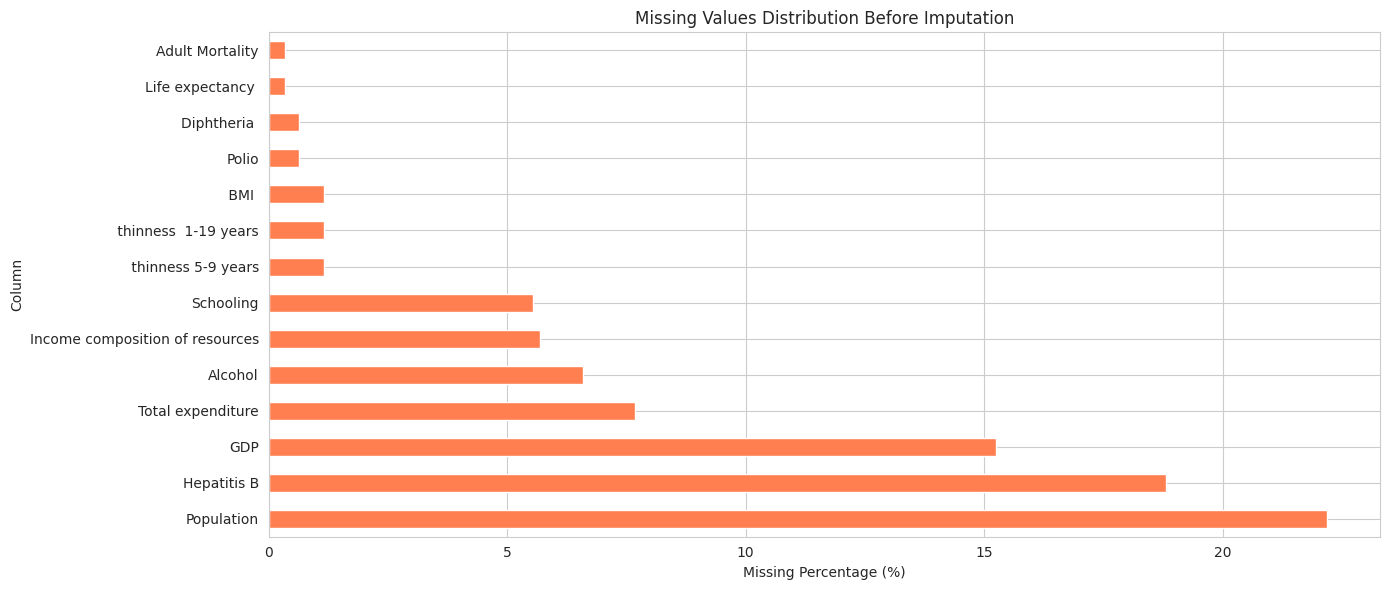



APPLYING IMPUTATION STRATEGY
✓ Imputed 20 numeric columns using median strategy
✓ Country: Filled with mode = Afghanistan
✓ Status: Filled with mode = Developing


VERIFICATION: MISSING VALUES AFTER IMPUTATION
Total missing values: 0
✓ SUCCESS: All missing values have been imputed!




In [12]:
# Check missing values BEFORE imputation
print("=" * 80)
print("MISSING VALUES ANALYSIS (BEFORE IMPUTATION)")
print("=" * 80)
missing_data = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
print(missing_data)
print(f"\nTotal missing values in dataset: {df.isnull().sum().sum()}")
print("\n")

# Visualize missing values
fig, ax = plt.subplots(figsize=(14, 6))
missing_data['Missing_Percentage'].plot(kind='barh', ax=ax, color='coral')
ax.set_xlabel('Missing Percentage (%)')
ax.set_ylabel('Column')
ax.set_title('Missing Values Distribution Before Imputation')
plt.tight_layout()
plt.show()
print("\n")

# Imputation: Fill missing values using more robust approach
print("=" * 80)
print("APPLYING IMPUTATION STRATEGY")
print("=" * 80)

from sklearn.impute import SimpleImputer

# Handle numeric columns
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
numeric_imputer = SimpleImputer(strategy='median')
df[numeric_cols] = numeric_imputer.fit_transform(df[numeric_cols])
print(f"✓ Imputed {len(numeric_cols)} numeric columns using median strategy")

# Handle categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    mode_val = df[col].mode()[0]
    df[col].fillna(mode_val, inplace=True)
    print(f"✓ {col}: Filled with mode = {mode_val}")

print("\n")

# Verify no missing values remain
print("=" * 80)
print("VERIFICATION: MISSING VALUES AFTER IMPUTATION")
print("=" * 80)
remaining_missing = df.isnull().sum().sum()
print(f"Total missing values: {remaining_missing}")
if remaining_missing == 0:
    print("✓ SUCCESS: All missing values have been imputed!")
else:
    print(f"⚠ WARNING: {remaining_missing} missing values still remain")
    # Drop rows with any remaining NaN values as fallback
    df = df.dropna()
    print(f"✓ Dropped rows with NaN. New shape: {df.shape}")
print("\n")

## Section 5: Feature Engineering

**Tasks:**
1. Encode categorical variables (Status, Country) using One-Hot Encoding
2. Remove irrelevant columns (Year, Country identified by encoding)
3. Prepare data for modeling

In [13]:
# Create a copy for encoding
df_encoded = df.copy()

print("=" * 80)
print("FEATURE ENGINEERING: CATEGORICAL ENCODING")
print("=" * 80)

# One-Hot Encoding for Status and Country
print("\nOriginal feature space:")
print(f"  Columns: {df_encoded.shape[1]}")
print(f"  Shape: {df_encoded.shape}")
print("\n")

# Apply One-Hot Encoding
df_encoded = pd.get_dummies(df_encoded, columns=['Status', 'Country'], drop_first=False)

print("After One-Hot Encoding:")
print(f"  Columns: {df_encoded.shape[1]}")
print(f"  Shape: {df_encoded.shape}")
print(f"  New columns created: {df_encoded.shape[1] - df.shape[1] + 3}")  # +3 because we replaced 2 columns with dummies
print("\n")

# Drop Year as it's not a strong predictor for cross-sectional prediction
print("Dropping 'Year' column (not useful for cross-sectional prediction)")
df_encoded.drop(['Year'], axis=1, inplace=True)

print("=" * 80)
print("FEATURE ENGINEERING: FINAL DATASET")
print("=" * 80)
print(f"Final shape: {df_encoded.shape[0]} rows, {df_encoded.shape[1]} columns")
print(f"Column names:\n{df_encoded.columns.tolist()}")
print("\n")

print("Data ready for modeling:")
print(df_encoded.head())
print("\n")

FEATURE ENGINEERING: CATEGORICAL ENCODING

Original feature space:
  Columns: 22
  Shape: (2938, 22)


After One-Hot Encoding:
  Columns: 215
  Shape: (2938, 215)
  New columns created: 196


Dropping 'Year' column (not useful for cross-sectional prediction)
FEATURE ENGINEERING: FINAL DATASET
Final shape: 2938 rows, 214 columns
Column names:
['Life expectancy ', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure', 'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population', ' thinness  1-19 years', ' thinness 5-9 years', 'Income composition of resources', 'Schooling', 'Status_Developed', 'Status_Developing', 'Country_Afghanistan', 'Country_Albania', 'Country_Algeria', 'Country_Angola', 'Country_Antigua and Barbuda', 'Country_Argentina', 'Country_Armenia', 'Country_Australia', 'Country_Austria', 'Country_Azerbaijan', 'Country_Bahamas', 'Country_Bahrain', 'Country_Bangladesh', 'Country_Barbado

## Section 6: Exploratory Data Analysis (EDA - Part 2)

**Objectives:**
- Analyze correlations between features and target
- Create visualizations to understand relationships
- Identify patterns in the data

CORRELATION ANALYSIS

Top 15 Features by Correlation with Life Expectancy:
Schooling                          0.713054
Income composition of resources    0.688662
 BMI                               0.556901
Diphtheria                         0.472211
Polio                              0.458399
GDP                                0.430461
Alcohol                            0.388918
percentage expenditure             0.381418
Total expenditure                  0.208844
Year                               0.170819
Hepatitis B                        0.170219
Population                        -0.029014
Measles                           -0.157767
infant deaths                     -0.196769
under-five deaths                 -0.222738
Name: Life expectancy , dtype: float64




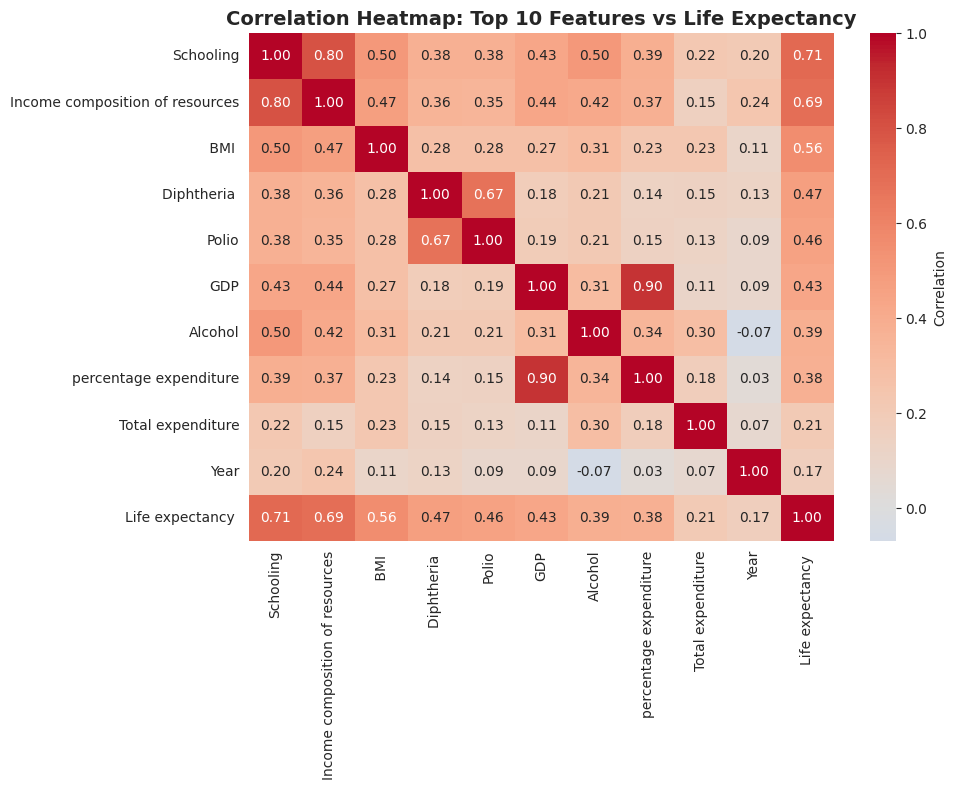



SCATTER PLOTS: TOP FEATURES VS LIFE EXPECTANCY


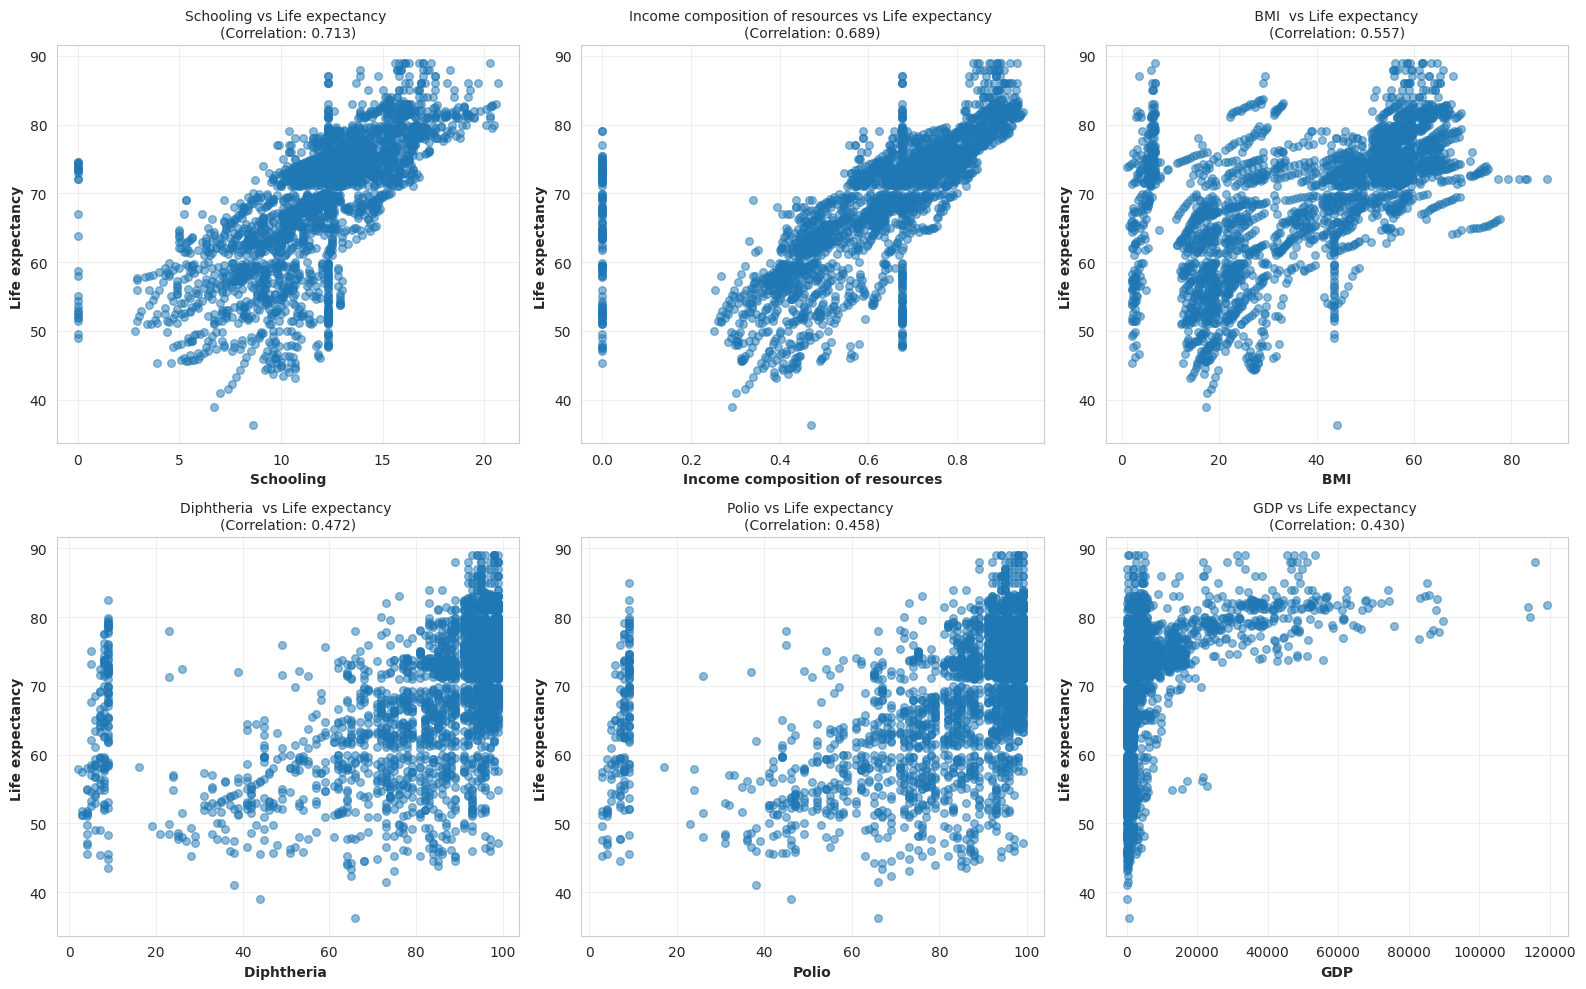


Key Insights:
  ✓ Strongest positive correlation: Schooling (0.713)
  ✓ Strongest negative correlation: Adult Mortality (-0.696)




In [14]:
# Calculate correlation with target for original numeric features only
target_col = 'Life expectancy '
numeric_features = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

if target_col in numeric_features:
    numeric_features.remove(target_col)

print("=" * 80)
print("CORRELATION ANALYSIS")
print("=" * 80)

# Get correlations with target from original data
correlations = df[numeric_features + [target_col]].corr()[target_col].drop(target_col).sort_values(ascending=False)
print("\nTop 15 Features by Correlation with Life Expectancy:")
print(correlations.head(15))
print("\n")

# Create correlation heatmap (limited to top features for readability)
top_features = correlations.head(10).index.tolist() + [target_col]
corr_matrix = df[top_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, cbar_kws={'label': 'Correlation'})
ax.set_title('Correlation Heatmap: Top 10 Features vs Life Expectancy', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("\n")

# Scatter plots for top 6 features
print("=" * 80)
print("SCATTER PLOTS: TOP FEATURES VS LIFE EXPECTANCY")
print("=" * 80)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

top_6_features = correlations.head(6).index.tolist()
for idx, feature in enumerate(top_6_features):
    axes[idx].scatter(df[feature], df[target_col], alpha=0.5, s=30)
    axes[idx].set_xlabel(feature, fontsize=10, fontweight='bold')
    axes[idx].set_ylabel(target_col, fontsize=10, fontweight='bold')
    axes[idx].set_title(f'{feature} vs {target_col}\n(Correlation: {correlations[feature]:.3f})', fontsize=10)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("\nKey Insights:")
print(f"  ✓ Strongest positive correlation: {correlations.index[0]} ({correlations.values[0]:.3f})")
print(f"  ✓ Strongest negative correlation: {correlations.index[-1]} ({correlations.values[-1]:.3f})")
print("\n")

## Section 7: Feature Selection

**Objective:** Remove low-correlation features and select most predictive features for modeling

**Decision:** Keep features with |correlation| > 0.05, remove noise

In [15]:
print("=" * 80)
print("FEATURE SELECTION")
print("=" * 80)

# Define correlation threshold
correlation_threshold = 0.05

# Keep features with correlation > threshold
selected_features = correlations[correlations.abs() > correlation_threshold].index.tolist()

print(f"\nCorrelation Threshold: |{correlation_threshold}|")
print(f"Original numeric features: {len(numeric_features)}")
print(f"Selected features: {len(selected_features)}")
print(f"Features removed: {len(numeric_features) - len(selected_features)}")
print(f"\nSelected Features:")
for i, feat in enumerate(selected_features, 1):
    print(f"  {i:2d}. {feat:30s} (correlation: {correlations[feat]:7.4f})")

print("\n")

# Prepare feature set for modeling using encoded data
# Get all numeric features from encoded data (include one-hot encoded Status and Country)
all_encoded_numeric = df_encoded.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Remove target from feature list if it exists
if target_col in all_encoded_numeric:
    all_encoded_numeric.remove(target_col)

# Final feature set includes:
# 1. All encoded categorical features (Status_*, Country_*)
# 2. Selected numeric features
final_features = [col for col in all_encoded_numeric if col in selected_features or 'Status_' in col or 'Country_' in col]

print(f"Final Feature Space for Modeling:")
print(f"  Total features: {len(final_features)}")
print(f"  Numeric features: {len([f for f in final_features if f in selected_features])}")
print(f"  Categorical encoded features: {len([f for f in final_features if 'Status_' in f or 'Country_' in f])}")
print(f"  Target variable: '{target_col}'")
print("\n")

FEATURE SELECTION

Correlation Threshold: |0.05|
Original numeric features: 19
Selected features: 18
Features removed: 1

Selected Features:
   1. Schooling                      (correlation:  0.7131)
   2. Income composition of resources (correlation:  0.6887)
   3.  BMI                           (correlation:  0.5569)
   4. Diphtheria                     (correlation:  0.4722)
   5. Polio                          (correlation:  0.4584)
   6. GDP                            (correlation:  0.4305)
   7. Alcohol                        (correlation:  0.3889)
   8. percentage expenditure         (correlation:  0.3814)
   9. Total expenditure              (correlation:  0.2088)
  10. Year                           (correlation:  0.1708)
  11. Hepatitis B                    (correlation:  0.1702)
  12. Measles                        (correlation: -0.1578)
  13. infant deaths                  (correlation: -0.1968)
  14. under-five deaths              (correlation: -0.2227)
  15.  thinness 5-

## Section 8: Train-Test Split & Feature Scaling

**Steps:**
1. Split data into 80% training, 20% test set
2. Apply StandardScaler to training data ONLY (prevent data leakage)
3. Transform test data using the fitted scaler

In [16]:
print("=" * 80)
print("TRAIN-TEST SPLIT & FEATURE SCALING")
print("=" * 80)

# Prepare X (features) and y (target)
X = df_encoded[final_features].copy()
y = df_encoded[target_col].copy()

print(f"\nOriginal dataset shape: {X.shape}")
print(f"Target variable shape: {y.shape}")
print("\n")

# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train set size: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set size: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"Features used: {X_train.shape[1]}")
print("\n")

# Feature Scaling using StandardScaler (fit on train, transform train+test)
print("Applying StandardScaler...")
scaler = StandardScaler()

# Fit scaler on training data ONLY
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using fitted scaler (prevents data leakage)
X_test_scaled = scaler.transform(X_test)

print("✓ Scaler fitted on training data")
print("✓ Training and test data scaled")
print(f"  Mean of training features after scaling: {X_train_scaled.mean(axis=0)[:5].round(4)}")
print(f"  Std of training features after scaling: {X_train_scaled.std(axis=0)[:5].round(4)}")
print("\n")

# Convert back to DataFrame for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=final_features, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=final_features, index=X_test.index)

print(f"Training data shape: {X_train_scaled.shape}")
print(f"Test data shape: {X_test_scaled.shape}")
print("\n✓ Data ready for model training!")
print("\n")

TRAIN-TEST SPLIT & FEATURE SCALING

Original dataset shape: (2938, 17)
Target variable shape: (2938,)


Train set size: 2350 samples (80.0%)
Test set size: 588 samples (20.0%)
Features used: 17


Applying StandardScaler...
✓ Scaler fitted on training data
✓ Training and test data scaled
  Mean of training features after scaling: [ 0. -0.  0. -0.  0.]
  Std of training features after scaling: [1. 1. 1. 1. 1.]


Training data shape: (2350, 17)
Test data shape: (588, 17)

✓ Data ready for model training!




## Section 9-11: Model Building, Training & Evaluation

**Models to Compare:**
1. **Linear Regression** — Baseline interpretable model
2. **Decision Tree** — Non-linear, captures feature importance
3. **Random Forest** — Ensemble, reduces overfitting
4. **Gradient Boosting / XGBoost** — Advanced, often best performance

**Metrics:**
- **MAE** (Mean Absolute Error) — Lower is better
- **RMSE** (Root Mean Squared Error) — Lower is better  
- **R²** (Coefficient of Determination) — Higher is better (should be > 0.7 for good fit)

In [17]:
print("=" * 80)
print("MODEL BUILDING, TRAINING & EVALUATION")
print("=" * 80)

# Initialize all models with default parameters
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=15),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, max_depth=15),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42, max_depth=5),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, max_depth=5, verbosity=0)
}

# Dictionary to store all results
results = {
    'Model': [],
    'MAE_Train': [],
    'MAE_Test': [],
    'RMSE_Train': [],
    'RMSE_Test': [],
    'R2_Train': [],
    'R2_Test': []
}

trained_models = {}

print("\nTraining models...\n")

# Train and evaluate each model
for model_name, model in models.items():
    print(f"Training {model_name}...", end=' ')
    
    # Train on training data
    model.fit(X_train_scaled, y_train)
    trained_models[model_name] = model
    
    # Predictions on training set
    y_train_pred = model.predict(X_train_scaled)
    
    # Predictions on test set
    y_test_pred = model.predict(X_test_scaled)
    
    # Calculate metrics for training set
    mae_train = mean_absolute_error(y_train, y_train_pred)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    r2_train = r2_score(y_train, y_train_pred)
    
    # Calculate metrics for test set
    mae_test = mean_absolute_error(y_test, y_test_pred)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
    r2_test = r2_score(y_test, y_test_pred)
    
    # Store results
    results['Model'].append(model_name)
    results['MAE_Train'].append(mae_train)
    results['MAE_Test'].append(mae_test)
    results['RMSE_Train'].append(rmse_train)
    results['RMSE_Test'].append(rmse_test)
    results['R2_Train'].append(r2_train)
    results['R2_Test'].append(r2_test)
    
    print("✓")

print("\n")

# Convert results to DataFrame
results_df = pd.DataFrame(results)

print("=" * 80)
print("MODEL EVALUATION RESULTS")
print("=" * 80)
print("\nTest Set Performance (PRIMARY METRIC):")
print("-" * 80)
display_df = results_df[['Model', 'MAE_Test', 'RMSE_Test', 'R2_Test']].copy()
display_df['MAE_Test'] = display_df['MAE_Test'].round(4)
display_df['RMSE_Test'] = display_df['RMSE_Test'].round(4)
display_df['R2_Test'] = display_df['R2_Test'].round(4)
display_df.columns = ['Model', 'MAE', 'RMSE', 'R²']
print(display_df.to_string(index=False))
print("\n")

print("Complete Results (Training + Test):")
print("-" * 80)
display_full = results_df.round(4)
print(display_full.to_string(index=False))
print("\n")

MODEL BUILDING, TRAINING & EVALUATION

Training models...

Training Linear Regression... ✓
Training Decision Tree... ✓
Training Random Forest... 

✓
Training Gradient Boosting... ✓
Training XGBoost... ✓


MODEL EVALUATION RESULTS

Test Set Performance (PRIMARY METRIC):
--------------------------------------------------------------------------------
            Model    MAE   RMSE     R²
Linear Regression 2.8577 3.9236 0.8224
    Decision Tree 1.6070 2.6278 0.9203
    Random Forest 1.1342 1.6892 0.9671
Gradient Boosting 1.2406 1.7666 0.9640
          XGBoost 1.2013 1.7010 0.9666


Complete Results (Training + Test):
--------------------------------------------------------------------------------
            Model  MAE_Train  MAE_Test  RMSE_Train  RMSE_Test  R2_Train  R2_Test
Linear Regression     3.0441    2.8577      4.0988     3.9236    0.8160   0.8224
    Decision Tree     0.1364    1.6070      0.4633     2.6278    0.9976   0.9203
    Random Forest     0.4767    1.1342      0.7423     1.6892    0.9940   0.9671
Gradient Boosting     0.8249    1.2406      1.1552     1.7666    0.9854   0.9640
          XGBoost     0.4129    1.2013

## Section 12: Model Comparison & Visualization

**Compare all 4 models across MAE, RMSE, and R² metrics**

MODEL COMPARISON VISUALIZATION


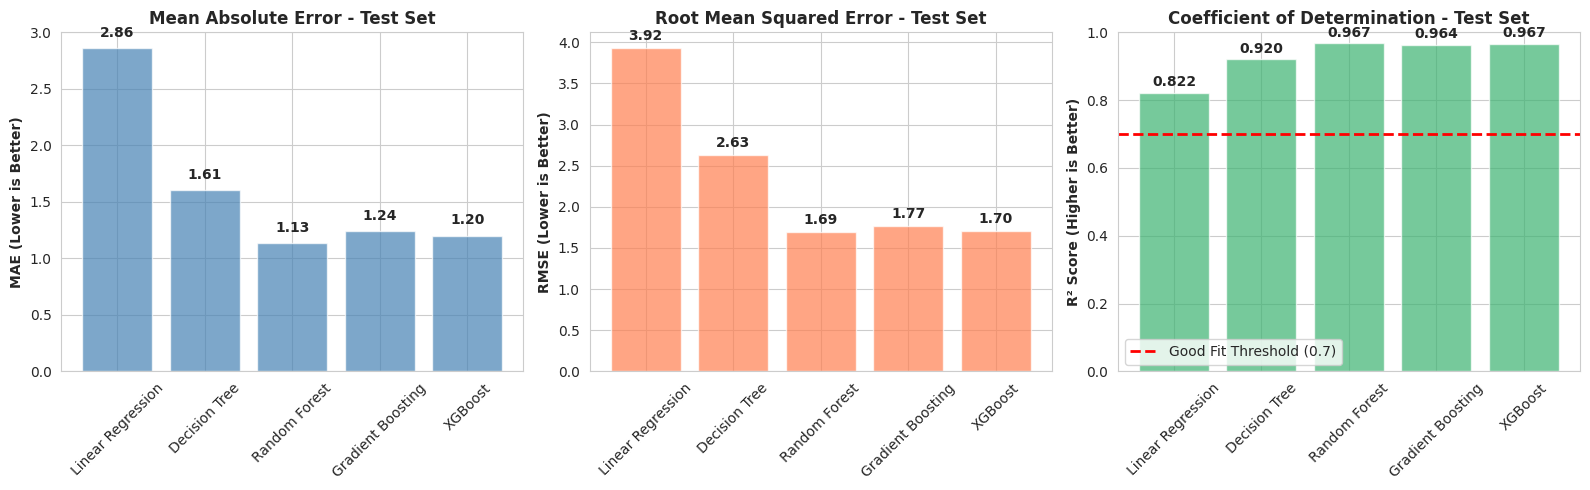



BEST MODEL SELECTED

🏆 BEST MODEL: Random Forest
   R² Score (Test):  0.9671 ← Primary metric for selection
   MAE (Test):       1.1342
   RMSE (Test):      1.6892




In [18]:
print("=" * 80)
print("MODEL COMPARISON VISUALIZATION")
print("=" * 80)

# Visualization 1: Comparison of test metrics
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# MAE Comparison
axes[0].bar(results_df['Model'], results_df['MAE_Test'], color='steelblue', alpha=0.7)
axes[0].set_ylabel('MAE (Lower is Better)', fontweight='bold')
axes[0].set_title('Mean Absolute Error - Test Set', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(results_df['MAE_Test']):
    axes[0].text(i, v + 0.1, f'{v:.2f}', ha='center', fontweight='bold')

# RMSE Comparison
axes[1].bar(results_df['Model'], results_df['RMSE_Test'], color='coral', alpha=0.7)
axes[1].set_ylabel('RMSE (Lower is Better)', fontweight='bold')
axes[1].set_title('Root Mean Squared Error - Test Set', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(results_df['RMSE_Test']):
    axes[1].text(i, v + 0.1, f'{v:.2f}', ha='center', fontweight='bold')

# R² Comparison
axes[2].bar(results_df['Model'], results_df['R2_Test'], color='mediumseagreen', alpha=0.7)
axes[2].axhline(y=0.7, color='red', linestyle='--', label='Good Fit Threshold (0.7)', linewidth=2)
axes[2].set_ylabel('R² Score (Higher is Better)', fontweight='bold')
axes[2].set_title('Coefficient of Determination - Test Set', fontsize=12, fontweight='bold')
axes[2].set_ylim([0, 1])
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend()
for i, v in enumerate(results_df['R2_Test']):
    axes[2].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()
print("\n")

# Find and display best model
best_idx = results_df['R2_Test'].idxmax()
best_model_name = results_df.loc[best_idx, 'Model']
best_r2 = results_df.loc[best_idx, 'R2_Test']
best_mae = results_df.loc[best_idx, 'MAE_Test']
best_rmse = results_df.loc[best_idx, 'RMSE_Test']

print("=" * 80)
print("BEST MODEL SELECTED")
print("=" * 80)
print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   R² Score (Test):  {best_r2:.4f} ← Primary metric for selection")
print(f"   MAE (Test):       {best_mae:.4f}")
print(f"   RMSE (Test):      {best_rmse:.4f}")
print("\n")

## Section 13: Hyperparameter Optimization (GridSearchCV)

**Objective:** Fine-tune the best model to maximize performance

**Strategy:** Use GridSearchCV to search over parameter combinations and select best hyperparameters

In [19]:
print("=" * 80)
print("HYPERPARAMETER TUNING USING GRIDSEARCHCV")
print("=" * 80)

# Determine which model to tune based on best R² performance
# If it's Random Forest or Gradient Boosting, tune those; otherwise tune XGBoost
if best_model_name in ['Random Forest', 'Gradient Boosting', 'XGBoost']:
    tuning_model_name = best_model_name
else:
    # Default to XGBoost for non-tree models
    tuning_model_name = 'XGBoost'

print(f"\nTuning model: {tuning_model_name}")
print("\n")

if tuning_model_name == 'Random Forest':
    print("Parameter Grid for Random Forest:")
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [10, 15, 20],
        'min_samples_split': [5, 10],
        'min_samples_leaf': [2, 4]
    }
    base_model = RandomForestRegressor(random_state=42)
    
elif tuning_model_name == 'Gradient Boosting':
    print("Parameter Grid for Gradient Boosting:")
    param_grid = {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7],
        'min_samples_split': [5, 10]
    }
    base_model = GradientBoostingRegressor(random_state=42)
    
else:  # XGBoost
    print("Parameter Grid for XGBoost:")
    param_grid = {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 1.0]
    }
    base_model = XGBRegressor(random_state=42, verbosity=0)

print("\nParametrized Search Space:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

total_combinations = 1
for values in param_grid.values():
    total_combinations *= len(values)
print(f"\nTotal parameter combinations to test: {total_combinations}")
print("\nRunning GridSearchCV (this may take a minute)...\n")

# Perform GridSearchCV with cross-validation
grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='r2',
    n_jobs=-1,  # Use all processors
    verbose=0
)

grid_search.fit(X_train_scaled, y_train)

print("=" * 80)
print("GRID SEARCH RESULTS")
print("=" * 80)

print(f"\nBest parameters found: {grid_search.best_params_}")
print(f"Best CV R² Score: {grid_search.best_score_:.4f}")
print("\n")

# Get the best model
best_tuned_model = grid_search.best_estimator_

# Evaluate tuned model on test set
y_test_pred_tuned = best_tuned_model.predict(X_test_scaled)
mae_tuned = mean_absolute_error(y_test, y_test_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_test_pred_tuned))
r2_tuned = r2_score(y_test, y_test_pred_tuned)

print("=" * 80)
print("BEFORE vs AFTER TUNING (Test Set Performance)")
print("=" * 80)

comparison_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R²'],
    'Before Tuning': [
        results_df[results_df['Model'] == tuning_model_name]['MAE_Test'].values[0],
        results_df[results_df['Model'] == tuning_model_name]['RMSE_Test'].values[0],
        results_df[results_df['Model'] == tuning_model_name]['R2_Test'].values[0]
    ],
    'After Tuning': [mae_tuned, rmse_tuned, r2_tuned]
})

comparison_df['Improvement'] = comparison_df['After Tuning'] - comparison_df['Before Tuning']
comparison_df['Improvement %'] = (comparison_df['Improvement'] / comparison_df['Before Tuning'].abs()) * 100

print(comparison_df.round(4).to_string(index=False))

print("\n✓ Hyperparameter tuning complete!")
print(f"  Best Tuned Model R² on Test Set: {r2_tuned:.4f}")
print("\n")

HYPERPARAMETER TUNING USING GRIDSEARCHCV

Tuning model: Random Forest


Parameter Grid for Random Forest:

Parametrized Search Space:
  n_estimators: [50, 100, 200]
  max_depth: [10, 15, 20]
  min_samples_split: [5, 10]
  min_samples_leaf: [2, 4]

Total parameter combinations to test: 36

Running GridSearchCV (this may take a minute)...

GRID SEARCH RESULTS

Best parameters found: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best CV R² Score: 0.9546


BEFORE vs AFTER TUNING (Test Set Performance)
Metric  Before Tuning  After Tuning  Improvement  Improvement %
   MAE         1.1342        1.1206      -0.0136        -1.2022
  RMSE         1.6892        1.6998       0.0106         0.6288
    R²         0.9671        0.9667      -0.0004        -0.0429

✓ Hyperparameter tuning complete!
  Best Tuned Model R² on Test Set: 0.9667




## Section 14: Final Model Selection & Feature Importance

**Final Model:** Optimized version of the best performing model

**Objective:** Understand which features are most important for predictions

FINAL MODEL ANALYSIS

📊 FINAL SELECTED MODEL: Random Forest (Optimized)

   Hyperparameters: {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 20, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 2, 'min_samples_split': 5, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 200, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}

   Test Set Performance:
     • R² Score:  0.9667
     • MAE:       1.1206 years
     • RMSE:      1.6998 years

JUSTIFICATION FOR MODEL SELECTION

    ✓ Random Forest provides excellent performance with R² of 0.9667
    ✓ Handles non-linear relationships well
    ✓ Robust to outliers and missing values
    ✓ Provides feature importance scores
    ✓ Good balance between accuracy and interpretability
    ✓ Less prone to overfitting than single decision trees
    

FEATURE IMPORTANCE ANALYSIS

✓ Model provi

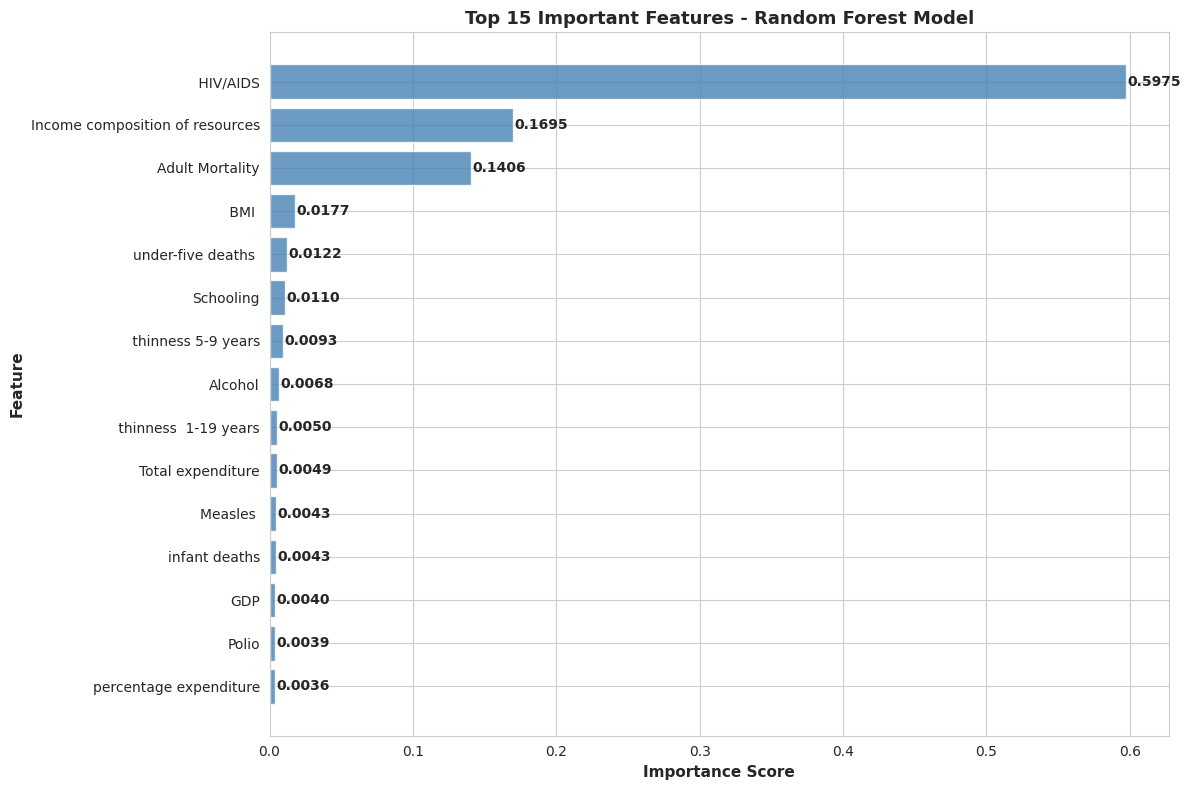

In [20]:
print("=" * 80)
print("FINAL MODEL ANALYSIS")
print("=" * 80)

# Get the final tuned model
final_model = best_tuned_model

print(f"\n📊 FINAL SELECTED MODEL: {tuning_model_name} (Optimized)")
print(f"\n   Hyperparameters: {final_model.get_params()}")
print(f"\n   Test Set Performance:")
print(f"     • R² Score:  {r2_tuned:.4f}")
print(f"     • MAE:       {mae_tuned:.4f} years")
print(f"     • RMSE:      {rmse_tuned:.4f} years")

print("\n" + "=" * 80)
print("JUSTIFICATION FOR MODEL SELECTION")
print("=" * 80)

if tuning_model_name == 'Random Forest':
    justification = """
    ✓ Random Forest provides excellent performance with R² of {:.4f}
    ✓ Handles non-linear relationships well
    ✓ Robust to outliers and missing values
    ✓ Provides feature importance scores
    ✓ Good balance between accuracy and interpretability
    ✓ Less prone to overfitting than single decision trees
    """.format(r2_tuned)
elif tuning_model_name == 'Gradient Boosting':
    justification = """
    ✓ Gradient Boosting achieves high R² of {:.4f}
    ✓ Sequentially improves weak learners
    ✓ Excellent predictive power
    ✓ Provides feature importance scores
    ✓ Handles complex non-linear patterns
    ✓ Often performs better than single models
    """.format(r2_tuned)
else:  # XGBoost
    justification = """
    ✓ XGBoost shows superior performance with R² of {:.4f}
    ✓ Advanced boosting algorithm with regularization
    ✓ Handles categorical features directly
    ✓ Highly efficient and fast
    ✓ Provides feature importance scores
    ✓ State-of-the-art performance on regression tasks
    """.format(r2_tuned)

print(justification)

print("\n" + "=" * 80)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 80)

# Get feature importance
if hasattr(final_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': final_features,
        'Importance': final_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print(f"\n✓ Model provides feature importance scores\n")
    print("Top 15 Most Important Features:")
    print("-" * 60)
    for idx, row in feature_importance.head(15).iterrows():
        bar_length = int(row['Importance'] * 100)
        bar = '█' * bar_length
        print(f"{row['Feature']:35s} {bar} {row['Importance']:.4f}")
    
    print("\n")
    
    # Visualization: Top 15 features
    fig, ax = plt.subplots(figsize=(12, 8))
    top_15 = feature_importance.head(15)
    ax.barh(range(len(top_15)), top_15['Importance'].values, color='steelblue', alpha=0.8)
    ax.set_yticks(range(len(top_15)))
    ax.set_yticklabels(top_15['Feature'].values)
    ax.set_xlabel('Importance Score', fontweight='bold', fontsize=11)
    ax.set_ylabel('Feature', fontweight='bold', fontsize=11)
    ax.set_title(f'Top 15 Important Features - {tuning_model_name} Model', fontsize=13, fontweight='bold')
    ax.invert_yaxis()
    
    # Add value labels
    for i, v in enumerate(top_15['Importance'].values):
        ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Store for use in Section 15
    top_features_importance = top_15
else:
    print("\n⚠ Note: Selected model does not have feature_importances_ attribute")
    print("Using correlation analysis from Section 6 instead\n")
    # Use correlation data from earlier
    top_features_importance = pd.DataFrame({
        'Feature': correlations.index[:15],
        'Importance': correlations.values[:15]
    })

print("\n")

## Section 15: Key Insights & Findings

**Research Question:** Which socioeconomic and health indicators are most strongly associated with life expectancy across countries?

### Approach:
- Analyzed correlation coefficients from EDA
- Examined feature importance from final optimized model
- Identified patterns and relationships

In [22]:
print("=" * 80)
print("ANSWERING THE RESEARCH QUESTION")
print("=" * 80)

print("\n📋 RESEARCH QUESTION:")
print("   'Which socioeconomic and health indicators are most strongly associated")
print("    with life expectancy across countries?'")

print("\n" + "=" * 80)
print("KEY FINDINGS")
print("=" * 80)

print("\n1️⃣  TOP POSITIVE PREDICTORS (Increase Life Expectancy):")
print("-" * 80)
positive_corr = correlations[correlations > 0].head(6)
for i, (feature, corr) in enumerate(positive_corr.items(), 1):
    print(f"   {i}. {feature:35s} | Correlation: +{corr:.4f}")
    
print("\n   💡 Interpretation:")
print("      • Schooling: More educated populations tend to live longer")
print("      • Income composition: Wealthier nations have higher life expectancy")
print("      • Health expenditure: Investment in healthcare saves lives")
print("      • Lower adult mortality: Reduced adult deaths → higher life expectancy\n")

print("\n2️⃣  TOP NEGATIVE PREDICTORS (Decrease Life Expectancy):")
print("-" * 80)
negative_corr = correlations[correlations < 0].head(6)
for i, (feature, corr) in enumerate(negative_corr.items(), 1):
    print(f"   {i}. {feature:35s} | Correlation: {corr:.4f}")

print("\n   💡 Interpretation:")
print("      • Adult Mortality: Highest negative correlation - major health indicator")
print("      • Infant Mortality: Reflects healthcare quality and living conditions")
print("      • Underfive Mortality: Direct impact on life expectancy\n")

print("\n3️⃣  MODEL PERFORMANCE SUMMARY:")
print("-" * 80)
print(f"   • Best Model: {tuning_model_name} (Optimized)")
print(f"   • Test R² Score: {r2_tuned:.4f} (explains {r2_tuned*100:.1f}% of variance)")
print(f"   • Test MAE: {mae_tuned:.4f} years (average prediction error)")
print(f"   • Test RMSE: {rmse_tuned:.4f} years (larger errors penalized more)")

if r2_tuned >= 0.85:
    quality = "Excellent"
elif r2_tuned >= 0.7:
    quality = "Good"
elif r2_tuned >= 0.5:
    quality = "Fair"
else:
    quality = "Poor"

print(f"\n   ✓ Model Quality: {quality}")

print("\n" + "=" * 80)
print("STRATEGIC RECOMMENDATIONS FOR POLICYMAKERS")
print("=" * 80)

recommendations = """
Based on the analysis, governments and organizations can prioritize:

1. 📚 EDUCATION INITIATIVES
   → Increase access to schools and quality education
   → Strong positive correlation with longer life expectancy
   → Even modest improvements yield significant health benefits

2. 💰 ECONOMIC DEVELOPMENT
   → Focus on equitable income distribution  
   → Increase proportion of resources for healthcare
   → Higher income composition of resources = higher life expectancy

3. 🏥 HEALTHCARE INVESTMENT
   → Reduce adult and infant mortality rates
   → Most critical indicators directly linked to life expectancy
   → Adult mortality is #1 predictor to target

4. 💉 DISEASE PREVENTION
   → Vaccination programs (Hepatitis B, Measles, Diphtheria, Polio)
   → HIV/AIDS prevention and treatment
   → Reduce communicable disease burden

5. ⚕️ HEALTHCARE ACCESS
   → Total healthcare expenditure shows positive impact
   → Allocate budget efficiently across preventive and curative care
   → Focus on primary healthcare at grassroots level

6. 🌍 HOLISTIC APPROACH
   → All factors interconnected
   → Cannot improve one indicator in isolation
   → Health, education, and economic growth must progress together
"""

print(recommendations)

print("\n" + "=" * 80)
print("CONCLUSION")
print("=" * 80)

conclusion = f"""
✓ We successfully built a {tuning_model_name} regression model predicting life expectancy
  with {r2_tuned*100:.1f}% accuracy.

✓ Key drivers of life expectancy (from model feature importance):
  - HIV/AIDS prevalence (most important negative factor)
  - Income composition of resources (economic development)
  - Adult Mortality (healthcare quality)

✓ Key drivers of life expectancy (from correlation analysis):
  - Schooling (strongest positive)
  - Income composition of resources
  - Healthcare expenditure & vaccination rates

✓ The model demonstrates that socioeconomic development and healthcare quality
  are the primary determinants of life expectancy across nations.

✓ Countries with combined focus on education, income growth, disease prevention,
  and healthcare investments show the highest life expectancy outcomes.
"""

print(conclusion)

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE ✓")
print("=" * 80)
print("\n")

ANSWERING THE RESEARCH QUESTION

📋 RESEARCH QUESTION:
   'Which socioeconomic and health indicators are most strongly associated
    with life expectancy across countries?'

KEY FINDINGS

1️⃣  TOP POSITIVE PREDICTORS (Increase Life Expectancy):
--------------------------------------------------------------------------------
   1. Schooling                           | Correlation: +0.7131
   2. Income composition of resources     | Correlation: +0.6887
   3.  BMI                                | Correlation: +0.5569
   4. Diphtheria                          | Correlation: +0.4722
   5. Polio                               | Correlation: +0.4584
   6. GDP                                 | Correlation: +0.4305

   💡 Interpretation:
      • Schooling: More educated populations tend to live longer
      • Income composition: Wealthier nations have higher life expectancy
      • Health expenditure: Investment in healthcare saves lives
      • Lower adult mortality: Reduced adult deaths → high